## Production Data Pipelines

Lesson Introduction

https://www.youtube.com/watch?v=n9-N24zCFHY

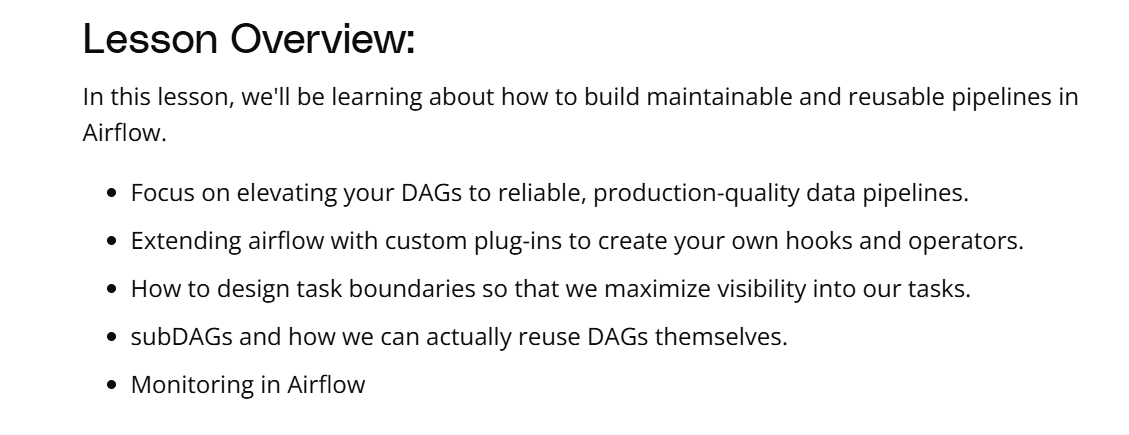

## Extending Airflow Hooks & Contrib

https://www.youtube.com/watch?v=5LSh41n7mP8

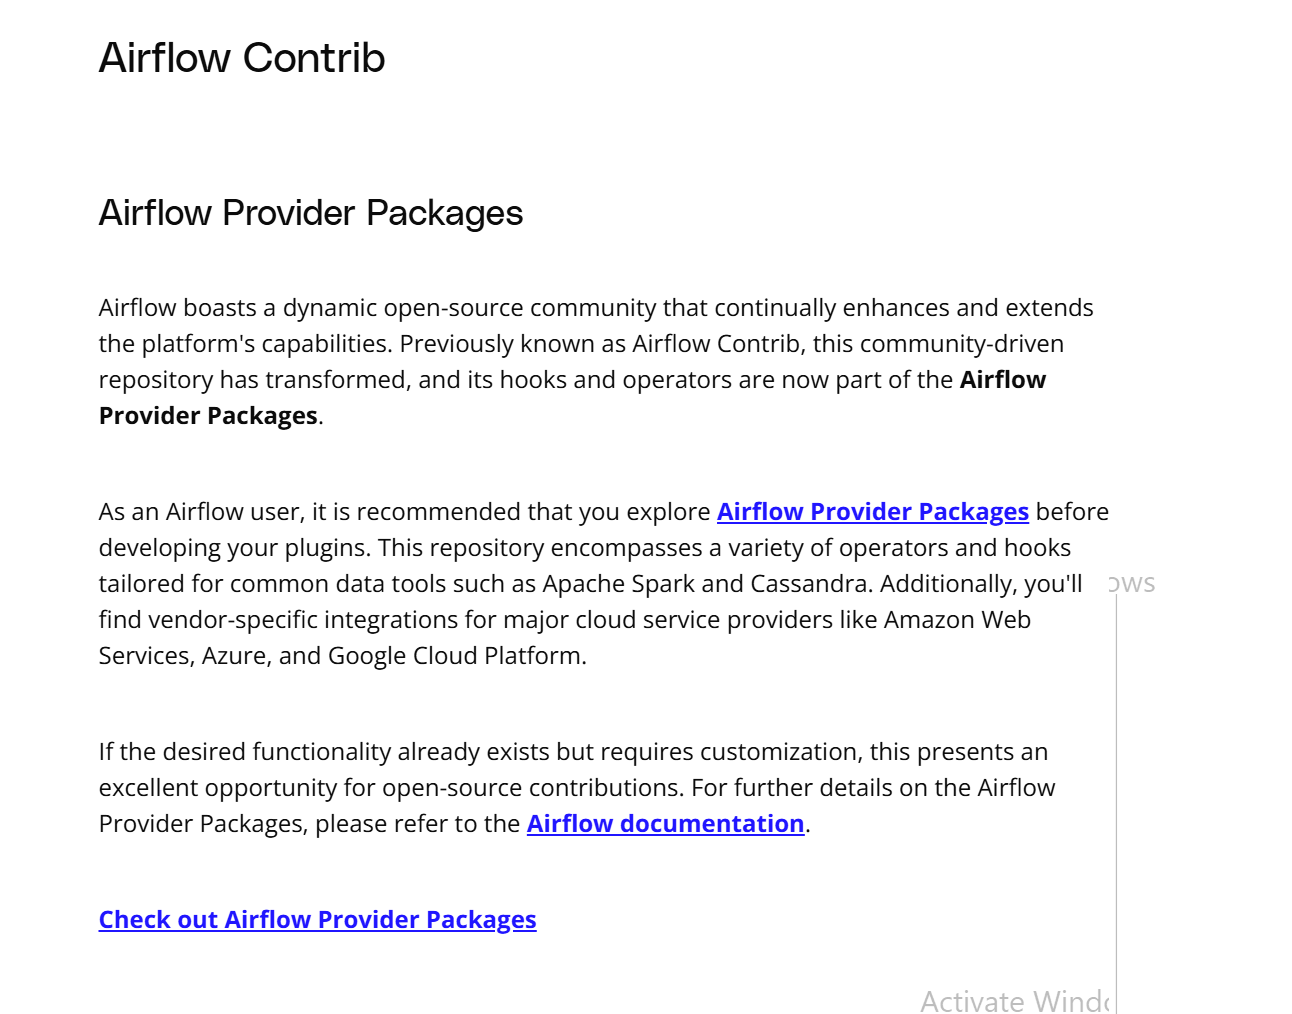

https://airflow.apache.org/docs/apache-airflow-providers/

https://airflow.apache.org/docs/apache-airflow-providers/

https://airflow.apache.org/docs/apache-airflow-providers/

## Extending Airflow with Plugins

https://www.youtube.com/watch?v=iRiqX4UyKHY

## Demo 1: Operator Plugins

https://www.youtube.com/watch?v=0mmSAbt8D3g

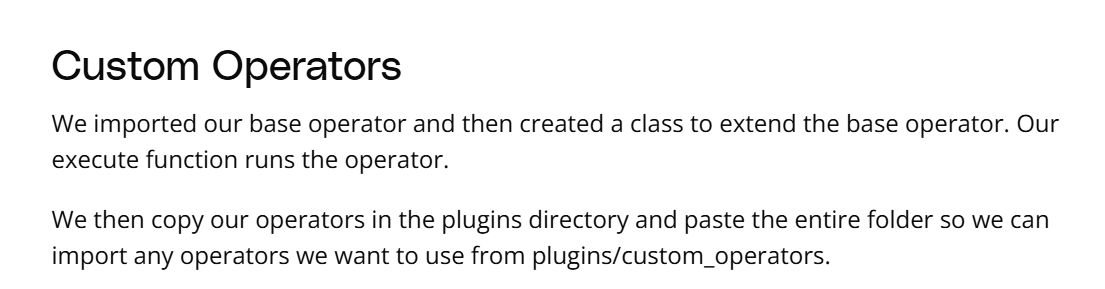

## Exercise 1: Operator Plugins

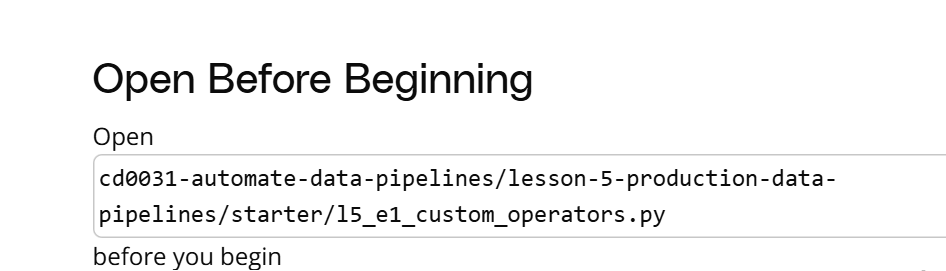

## Solution 1: Operator Plugins

https://www.youtube.com/watch?v=KplFrhONYkc

## Solution: Operator Plugins
In our solution, we consolidated repeated code into operator plugins. Remember that a custom operator is essentially a universal function able to be called in any DAG. Keep in mind that changing the code for an operator in one place will affect anywhere else it is called.

In [ ]:
import pendulum
import logging

from airflow.decorators import dag, task
from airflow.hooks.postgres_hook import PostgresHook

from airflow.operators.postgres_operator import PostgresOperator
from custom_operators.s3_to_redshift import S3ToRedshiftOperator
from custom_operators.has_rows import HasRowsOperator


from udacity.common import sql_statements

@dag(    
    start_date=pendulum.now(),
    max_active_runs=1
)

def demonstrate_custom_operators():

    @task()
    def check_greater_than_zero(*args,* *kwargs):
        table = kwargs["params"]["table"]
        redshift_hook = PostgresHook("redshift")
        records = redshift_hook.get_records(f"SELECT COUNT(*) FROM {table}")
        if len(records) < 1 or len(records[0]) < 1:
            raise ValueError(f"Data quality check failed. {table} returned no results")
        num_records = records[0][0]
        if num_records < 1:
            raise ValueError(f"Data quality check failed. {table} contained 0 rows")
        logging.info(f"Data quality on table {table} check passed with {records[0][0]} records")



    create_trips_table = PostgresOperator(
        task_id="create_trips_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_TRIPS_TABLE_SQL
    )

    copy_trips_task = S3ToRedshiftOperator(
        task_id="load_trips_from_s3_to_redshift",
        table="trips",
        redshift_conn_id="redshift",
        aws_credentials_id="aws_credentials",
        s3_bucket="sean-murdock",  # Update this value with the S3 bucket created at Airflow and AWS.
        s3_key="data-pipelines/divvy/unpartitioned/divvy_trips_2018.csv"
    )

    #
    # TODO: Replace this data quality check with the HasRowsOperator
    #
    check_trips_task = HasRowsOperator(
        task_id="count_trips",
        table="trips",
        redshift_conn_id="redshift",
    )



    create_stations_table = PostgresOperator(
        task_id="create_stations_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_STATIONS_TABLE_SQL,
    )

    copy_stations_task = S3ToRedshiftOperator(
        task_id="load_stations_from_s3_to_redshift",
        redshift_conn_id="redshift",
        aws_credentials_id="aws_credentials",
        s3_bucket="sean-murdock",  # Update this value with the S3 bucket created at Airflow and AWS.
        s3_key="data-pipelines/divvy/unpartitioned/divvy_stations_2017.csv",
        table="stations"
    )

#
# TODO: Replace this data quality check with the HasRowsOperator
#
    check_stations_task = HasRowsOperator(
        task_id="count_stations",
        table="stations",
        redshift_conn_id="redshift",        
    )

    create_trips_table >> copy_trips_task
    create_stations_table >> copy_stations_task
    copy_stations_task >> check_stations_task
    copy_trips_task >> check_trips_task

custom_operators_dag = demonstrate_custom_operators()

## Best Practices for Data Pipeline Steps - Task Boundaries

https://www.youtube.com/watch?v=XxhNFrkKuQo

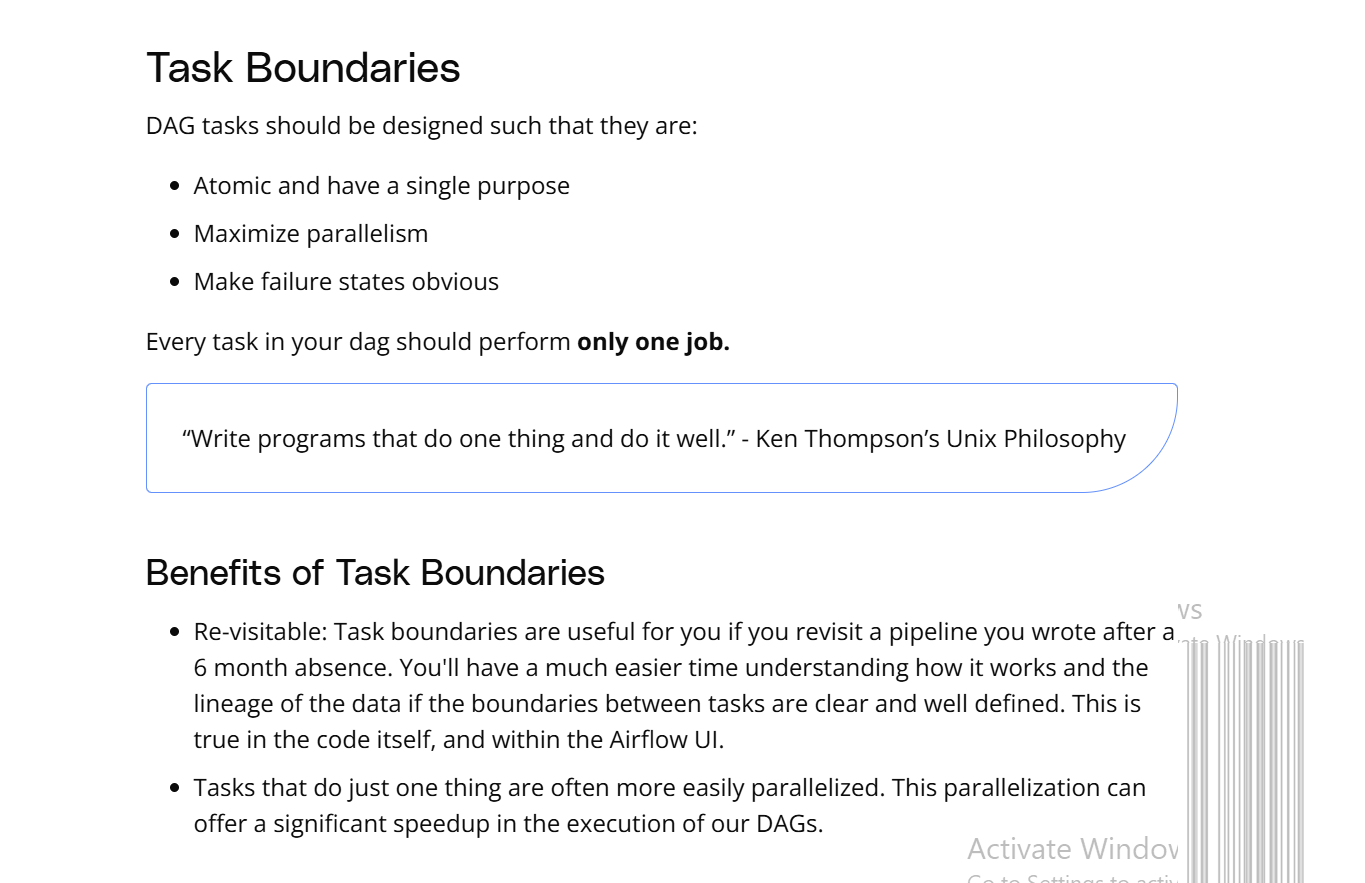

## Exercise 2: Refactor a DAG

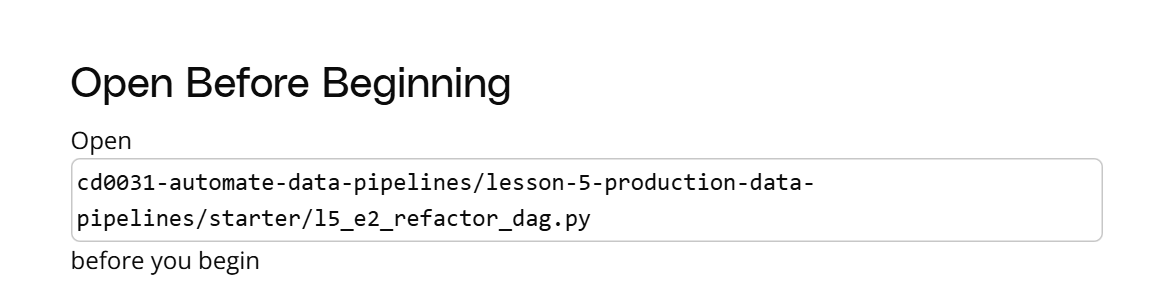

## Solution 2: Refactor a DAG

https://www.youtube.com/watch?v=k24wKVyrVlE

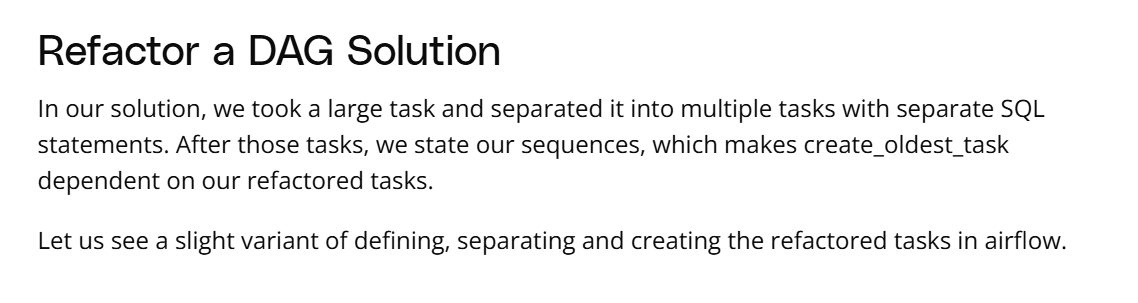

In [ ]:
import pendulum
import logging

from airflow.decorators import dag, task
from airflow.hooks.postgres_hook import PostgresHook

from airflow.operators.postgres_operator import PostgresOperator

@dag (
    start_date=pendulum.now()
)
def demonstrating_refactoring():

#
# TODO: Finish refactoring this function into the appropriate set of tasks,
#       instead of keeping this one large task.
#
    @task()
    def find_riders_under_18(*args,* *kwargs):
        redshift_hook = PostgresHook("redshift")

        # Find all trips where the rider was under 18
        redshift_hook.run("""
            BEGIN;
            DROP TABLE IF EXISTS younger_riders;
            CREATE TABLE younger_riders AS (
                SELECT * FROM trips WHERE birthyear > 2000
            );
            COMMIT;
        """)
        records = redshift_hook.get_records("""
            SELECT birthyear FROM younger_riders ORDER BY birthyear DESC LIMIT 1
        """)
        if len(records) > 0 and len(records[0]) > 0:
            logging.info(f"Youngest rider was born in {records[0][0]}")

    @task()
    def how_often_bikes_ridden(*args,* *kwargs):
        redshift_hook = PostgresHook("redshift")

        # Find out how often each bike is ridden
        redshift_hook.run("""
            BEGIN;
            DROP TABLE IF EXISTS lifetime_rides;
            CREATE TABLE lifetime_rides AS (
                SELECT bikeid, COUNT(bikeid)
                FROM trips
                GROUP BY bikeid
            );
            COMMIT;
        """)

    @task()
    def create_station_count(*args,* *kwargs):        
        redshift_hook = PostgresHook("redshift")
        # Count the number of stations by city
        redshift_hook.run("""
            BEGIN;
            DROP TABLE IF EXISTS city_station_counts;
            CREATE TABLE city_station_counts AS(
                SELECT city, COUNT(city)
                FROM stations
                GROUP BY city
            );
            COMMIT;
        """)

    @task()
    def log_oldest():
        redshift_hook = PostgresHook("redshift")
        records = redshift_hook.get_records("""
            SELECT birthyear FROM older_riders ORDER BY birthyear ASC LIMIT 1
        """)
        if len(records) > 0 and len(records[0]) > 0:
            logging.info(f"Oldest rider was born in {records[0][0]}")

    find_riders_under_18_task = find_riders_under_18()
    how_often_bikes_ridden_task = how_often_bikes_ridden()
    create_station_count_task=create_station_count()


    drop_oldest_task = PostgresOperator(
        task_id="drop_oldest",
        sql="""
            BEGIN;
            DROP TABLE IF EXISTS older_riders;
            COMMIT;
        """,
        postgres_conn_id="redshift"
    )

    create_oldest_task = PostgresOperator(
        task_id="create_oldest",
        sql="""
            BEGIN;
            CREATE TABLE older_riders AS (
                SELECT * FROM trips WHERE birthyear > 0 AND birthyear <= 1945
            );
            COMMIT;
        """,
        postgres_conn_id="redshift"
    )    

    log_oldest_task = log_oldest()

    [find_riders_under_18_task, how_often_bikes_ridden_task,
     create_station_count_task] >> drop_oldest_task

    drop_oldest_task >> create_oldest_task >> log_oldest_task


demonstrating_refactoring_dag = demonstrating_refactoring()

## Converting an Airflow 1 DAG

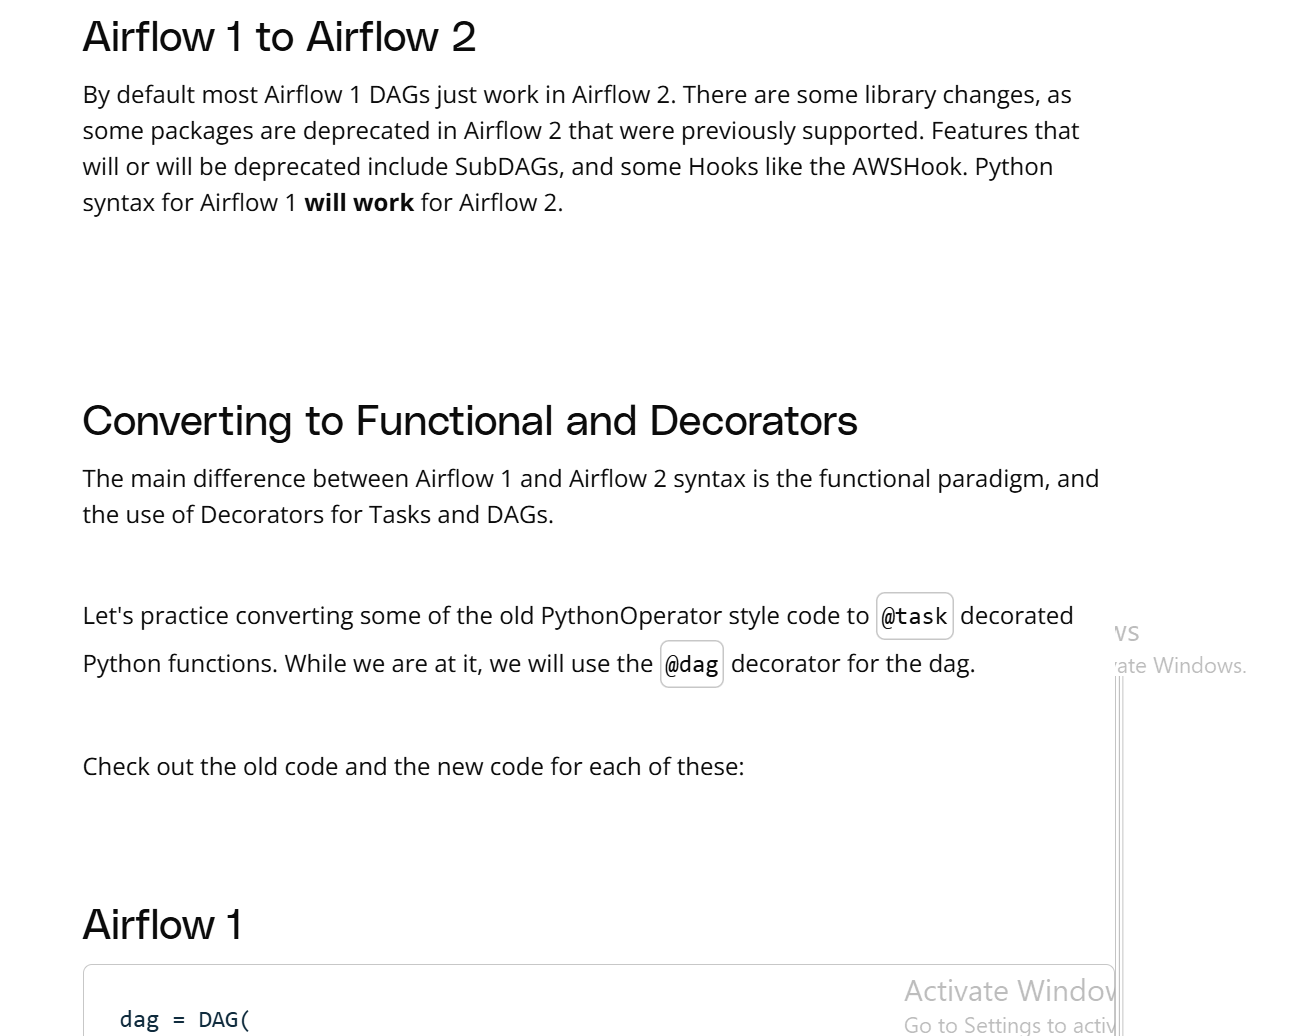

In [ ]:
dag = DAG(
    'data_quality_legacy',
    start_date=pendulum.datetime(2018, 1, 1, 0, 0, 0, 0),
    end_date=pendulum.datetime(2018, 12, 1, 0, 0, 0, 0),
    schedule_interval='@monthly',
    max_active_runs=1
)

def load_trip_data_to_redshift(*args,* *kwargs):
    metastoreBackend = MetastoreBackend()
    aws_connection=metastoreBackend.get_connection("aws_credentials")
    redshift_hook = PostgresHook("redshift")
    execution_date = kwargs["execution_date"]
    sql_stmt = sql_statements.COPY_MONTHLY_TRIPS_SQL.format(
        aws_connection.login,
        aws_connection.password,
        year=execution_date.year,
        month=execution_date.month
    )
    redshift_hook.run(sql_stmt)

load_trips_task = PythonOperator(
    task_id='load_trips_from_s3_to_redshift',
    dag=dag,
    python_callable=load_trip_data_to_redshift,
    provide_context=True,
    sla=datetime.timedelta(hours=1)
)

. . .

create_trips_table >> load_trips_taskdag = DAG(
    'data_quality_legacy',
    start_date=pendulum.datetime(2018, 1, 1, 0, 0, 0, 0),
    end_date=pendulum.datetime(2018, 12, 1, 0, 0, 0, 0),
    schedule_interval='@monthly',
    max_active_runs=1
)

def load_trip_data_to_redshift(*args,* *kwargs):
    metastoreBackend = MetastoreBackend()
    aws_connection=metastoreBackend.get_connection("aws_credentials")
    redshift_hook = PostgresHook("redshift")
    execution_date = kwargs["execution_date"]
    sql_stmt = sql_statements.COPY_MONTHLY_TRIPS_SQL.format(
        aws_connection.login,
        aws_connection.password,
        year=execution_date.year,
        month=execution_date.month
    )
    redshift_hook.run(sql_stmt)

load_trips_task = PythonOperator(
    task_id='load_trips_from_s3_to_redshift',
    dag=dag,
    python_callable=load_trip_data_to_redshift,
    provide_context=True,
    sla=datetime.timedelta(hours=1)
)

. . .

create_trips_table >> load_trips_task

## Airflow 2

In [ ]:
@dag(
    start_date=pendulum.datetime(2018, 1, 1, 0, 0, 0, 0),
    end_date=pendulum.datetime(2018, 12, 1, 0, 0, 0, 0),
    schedule_interval='@monthly',
    max_active_runs=1    
)
def data_quality():

    @task(sla=datetime.timedelta(hours=1))
    def load_trip_data_to_redshift(*args,* *kwargs):
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        execution_date = kwargs["execution_date"]
        sql_stmt = sql_statements.COPY_MONTHLY_TRIPS_SQL.format(
            aws_connection.login,
            aws_connection.password,
            year=execution_date.year,
            month=execution_date.month
        )
        redshift_hook.run(sql_stmt)

    load_trips_task = load_trip_data_to_redshift()

. . .

create_trips_table >> load_trips_task


## Exercise 3.1: Intro to Converting from Airflow1

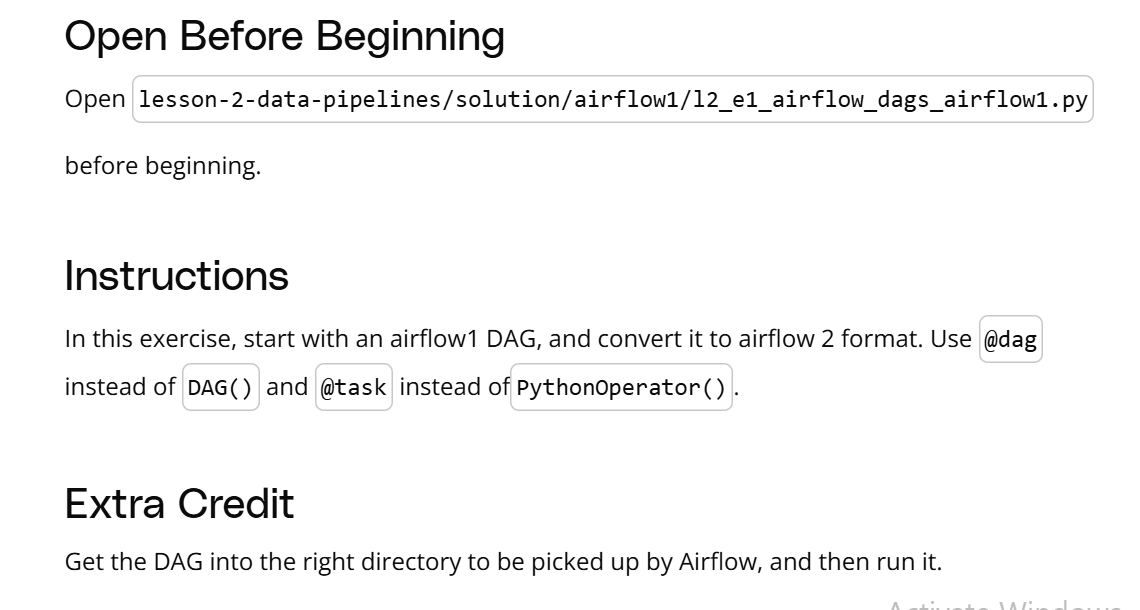

## Solution 3.1: Intro to Converting from Airflow1

https://www.youtube.com/watch?v=d7Z1pw6E6zM

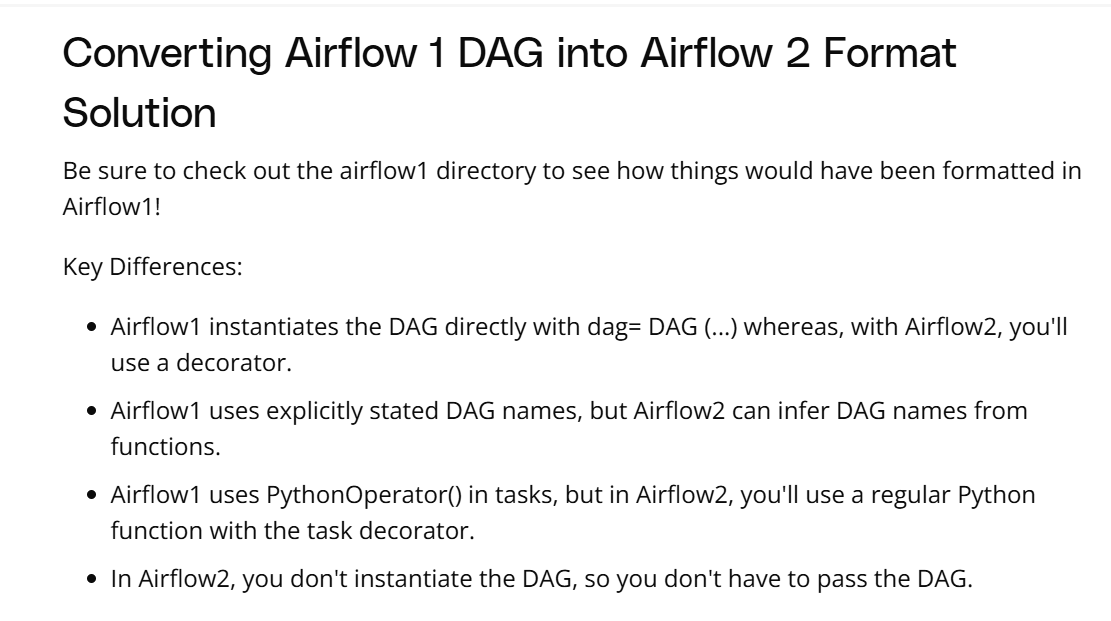

## Solution 3.2: Convert a Full Airflow 1 DAG

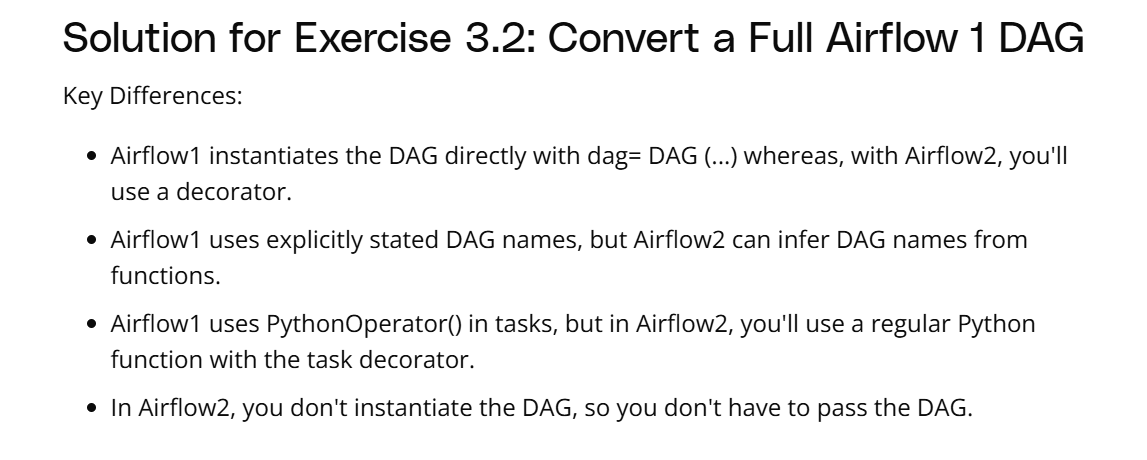

In [ ]:
import pendulum
import datetime
import logging

from airflow.decorators import dag,task
from airflow.secrets.metastore import MetastoreBackend
from airflow.hooks.postgres_hook import PostgresHook
from airflow.operators.postgres_operator import PostgresOperator
from airflow.operators.python_operator import PythonOperator

from udacity.common import sql_statements

@dag(
    start_date=pendulum.datetime(2018, 1, 1, 0, 0, 0, 0),
    end_date=pendulum.datetime(2018, 12, 1, 0, 0, 0, 0),
    schedule_interval='@monthly',
    max_active_runs=1    
)
def data_quality():

    @task(sla=datetime.timedelta(hours=1))
    def load_trip_data_to_redshift(*args,* *kwargs):
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        execution_date = kwargs["execution_date"]
        sql_stmt = sql_statements.COPY_MONTHLY_TRIPS_SQL.format(
            aws_connection.login,
            aws_connection.password,
            year=execution_date.year,
            month=execution_date.month
        )
        redshift_hook.run(sql_stmt)

    @task()
    def load_station_data_to_redshift(*args,* *kwargs):
        metastoreBackend = MetastoreBackend()
        aws_connection=metastoreBackend.get_connection("aws_credentials")
        redshift_hook = PostgresHook("redshift")
        sql_stmt = sql_statements.COPY_STATIONS_SQL.format(
            aws_connection.login,
            aws_connection.password,
        )
        redshift_hook.run(sql_stmt)

    @task()
    def check_greater_than_zero(*args,* *kwargs):
        table = kwargs["params"]["table"]
        redshift_hook = PostgresHook("redshift")
        records = redshift_hook.get_records(f"SELECT COUNT(*) FROM {table}")
        if len(records) < 1 or len(records[0]) < 1:
            raise ValueError(f"Data quality check failed. {table} returned no results")
        num_records = records[0][0]
        if num_records < 1:
            raise ValueError(f"Data quality check failed. {table} contained 0 rows")
        logging.info(f"Data quality on table {table} check passed with {records[0][0]} records")


    create_trips_table = PostgresOperator(
        task_id="create_trips_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_TRIPS_TABLE_SQL
    )

    load_trips_task = load_trip_data_to_redshift()


    check_trips_task = check_greater_than_zero(
        params={
            'table':'trips'
        }
    )

    create_stations_table = PostgresOperator(
        task_id="create_stations_table",
        postgres_conn_id="redshift",
        sql=sql_statements.CREATE_STATIONS_TABLE_SQL,
    )

    load_stations_task = load_station_data_to_redshift()

    check_stations_task = check_greater_than_zero(
        params={
            'table': 'stations',
        }
    )


    create_trips_table >> load_trips_task
    create_stations_table >> load_stations_task
    load_stations_task >> check_stations_task
    load_trips_task >> check_trips_task

data_quality_dag = data_quality()

## Monitoring

https://www.youtube.com/watch?v=UUt8MaradiM

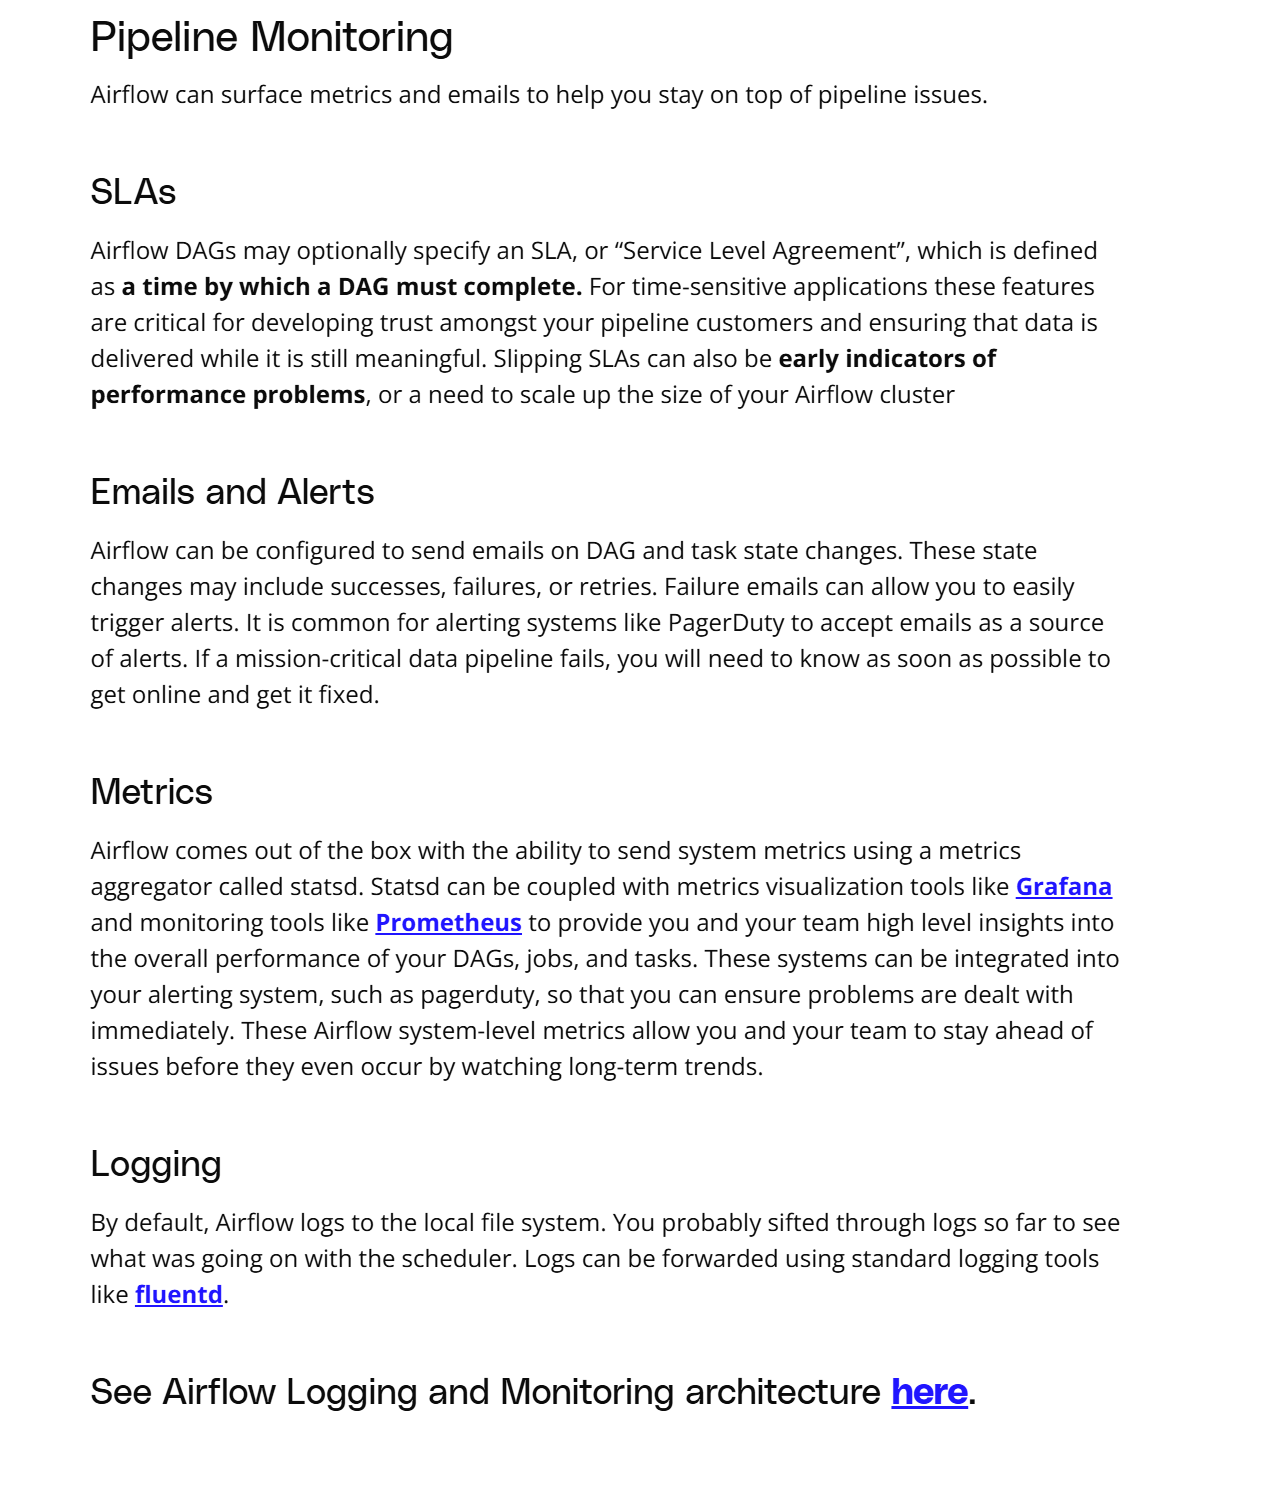

https://grafana.com/

https://prometheus.io/

https://www.fluentd.org/

https://airflow.apache.org/docs/apache-airflow/stable/logging-monitoring/logging-architecture.html

## Monitoring Quiz

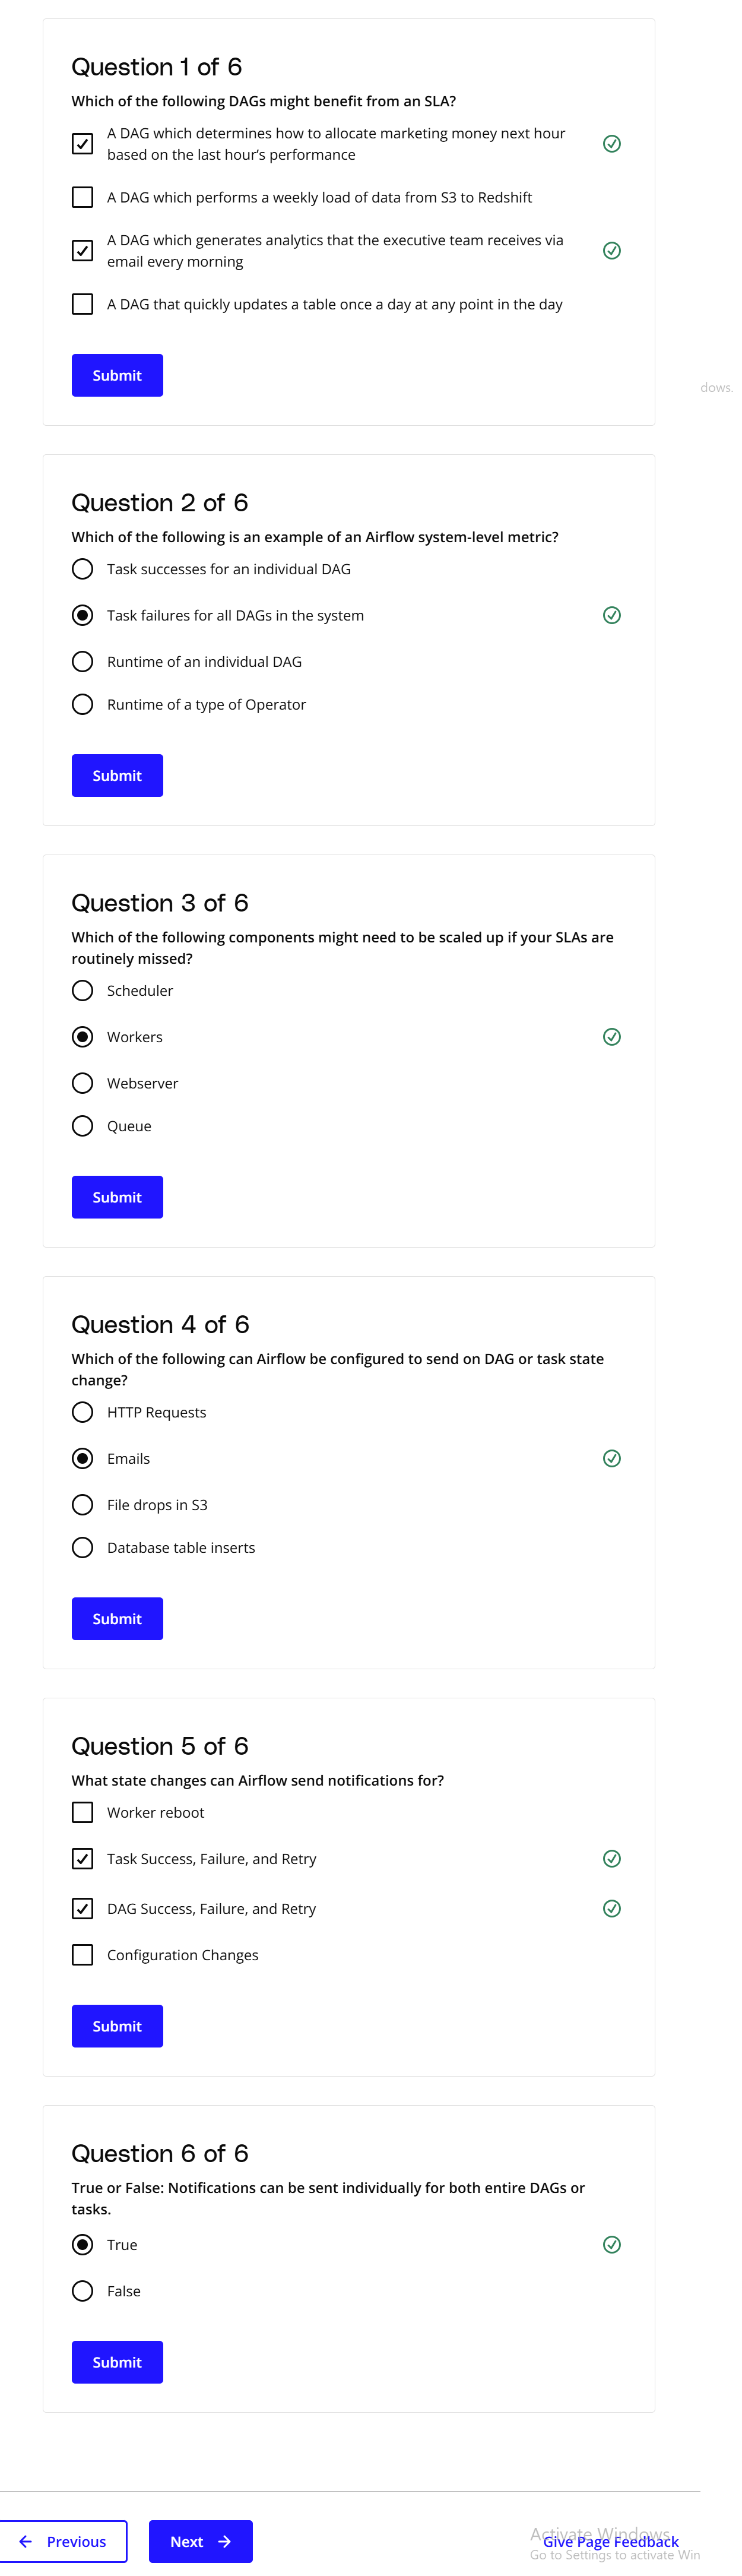

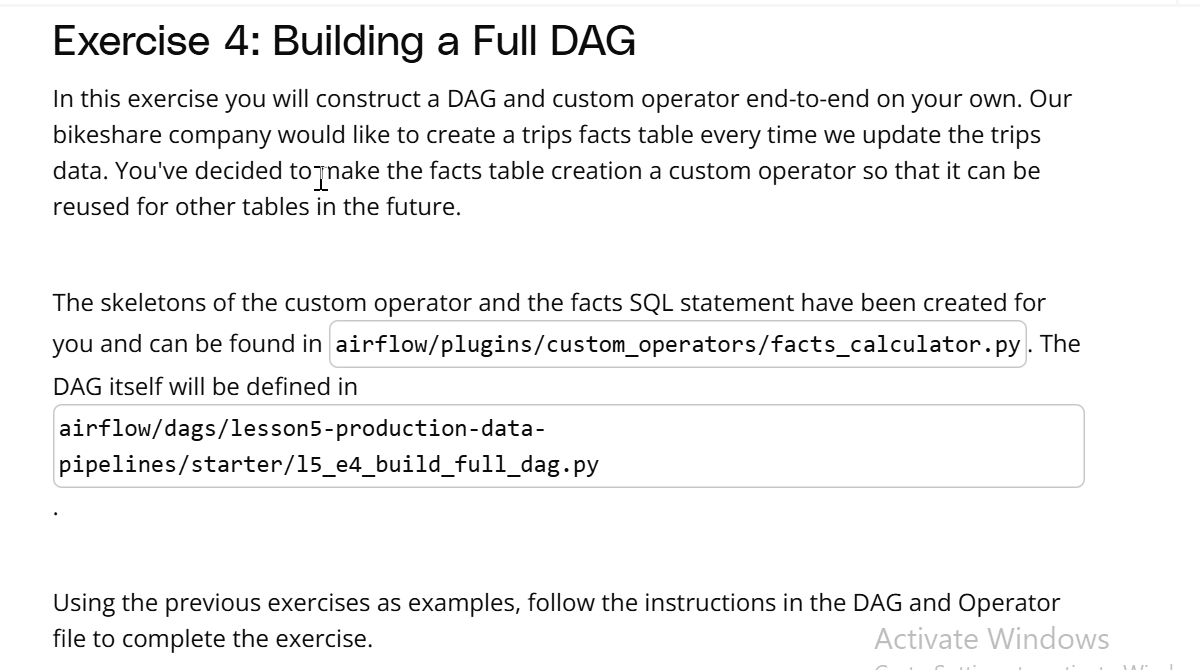

## Exercise 4: Building a Full DAG

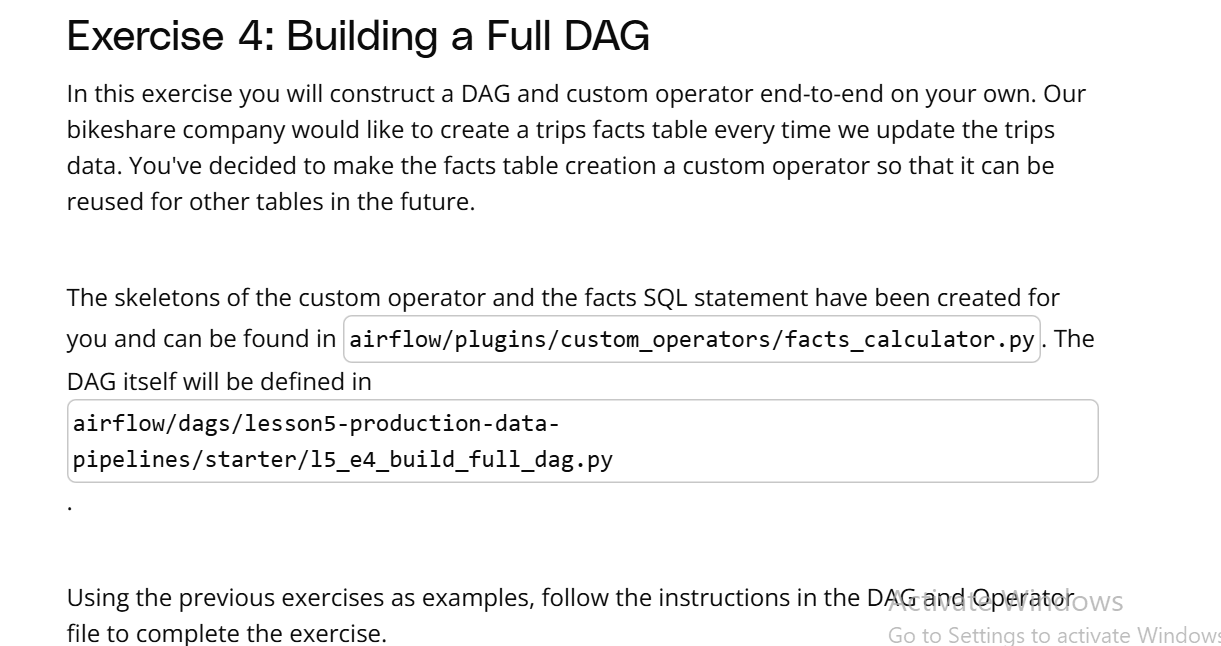